In [5]:
from pathlib import Path
import pandas as pd
import geopandas as gp
from shapely.geometry import point
import numpy as np
import matplotlib.pyplot as plt
import scipy as st
import seaborn as sns

In [6]:
DATA_DIR = Path.cwd().parent / "data"
df = pd.read_csv(DATA_DIR / "processed" / "cleaned_taxi_data.csv")
pd.set_option('display.float_format', '{:.2f}'.format)

In [7]:
df.head(5)

,index_left,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,BoroName
0,4217,id1693416,2,2016-01-12 22:57:13,2016-01-12 23:33:06,1,-73.98,40.73,-74.07,40.64,N,35.88,Staten Island
1,16494,id1973056,2,2016-03-22 15:35:52,2016-03-22 16:53:17,1,-73.79,40.65,-74.14,40.62,N,77.42,Staten Island
2,17985,id3759847,2,2016-02-04 22:00:26,2016-02-04 22:48:18,2,-73.98,40.74,-74.08,40.60,N,47.87,Staten Island
3,19015,id3330882,2,2016-04-02 08:47:43,2016-04-02 08:50:23,1,-74.07,40.62,-74.07,40.62,N,2.67,Staten Island
4,19701,id0778469,1,2016-01-01 19:46:50,2016-01-01 20:33:26,1,-73.99,40.75,-74.12,40.57,N,46.60,Staten Island


Checking for any Nulls in the data

In [8]:
df.isna().sum()

index_left            0
id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
BoroName              0
dtype: int64

In [9]:
df.describe()

,index_left,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1442002.00,1442002.00,1442002.00,1442002.00,1442002.00,1442002.00,1442002.00,1442002.00
mean,729358.25,1.53,1.67,-73.97,40.75,-73.97,40.75,13.93
std,421072.30,0.50,1.32,0.04,0.03,0.03,0.03,10.78
min,0.00,1.00,0.00,-74.32,40.21,-74.24,40.51,1.00
25%,364764.25,1.00,1.00,-73.99,40.74,-73.99,40.74,6.67
50%,729371.50,2.00,1.00,-73.98,40.75,-73.98,40.75,11.05
75%,1094040.75,2.00,2.00,-73.97,40.77,-73.96,40.77,17.85
max,1458643.00,2.00,6.00,-72.81,51.88,-73.70,40.91,119.85


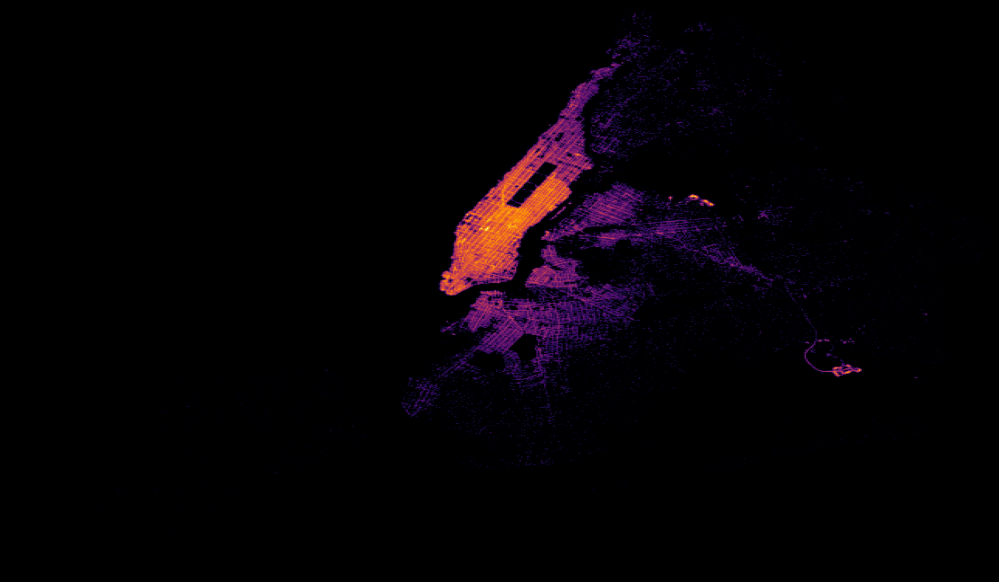

In [21]:

geometry  = gp.points_from_xy(df['dropoff_longitude'],df['dropoff_latitude'])
from scipy.ndimage import gaussian_filter
gdf  = gp.GeoDataFrame(df,geometry=geometry,crs='EPSG:4326')
x = gdf['dropoff_longitude'].values
y = gdf['dropoff_latitude'].values
xy = np.vstack([x,y])
density, xedges, yedges = np.histogram2d(x, y, bins=600)
density_smooth = gaussian_filter(density, sigma=0.4)
plt.figure(figsize=(12,7))
fig = plt.gcf()
ax = plt.gca()
fig.patch.set_facecolor('black')
ax.set_facecolor('black')
plt.imshow(
    np.rot90(density_smooth),
    cmap ='inferno',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect = 'auto',
    norm = plt.matplotlib.colors.LogNorm(vmin=1)
)
FIGURES_DIR = Path.cwd().parent / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "NYC_img.png")

From the above plot we can see where the majority of the taxi rides takes place in the city

Now using haversine distance formula to calculate distance between the pickup and dropoff points as a feature

$$
\begin{aligned}
a &= \sin^2\left(\frac{\Delta \varphi}{2}\right) + \cos(\varphi_1) \cos(\varphi_2) \sin^2\left(\frac{\Delta \lambda}{2}\right) \\
c &= 2 \arcsin\left(\sqrt{a}\right) \\
d &= R \cdot c
\end{aligned}
$$

The formula in Python

In [11]:
def haversine_form(lat1,long1,lat2,long2):
    lat1 , long1,lat2,long2 = map(np.radians, [lat1, long1, lat2, long2])
    dlat = lat2-lat1
    dlong = long2-long1
    a  = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2)*np.sin(dlong/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 3956
    return c*r

In [12]:
df['distance'] = haversine_form(df['pickup_latitude'],df['pickup_longitude'],df['dropoff_latitude'],df['dropoff_longitude'])

Now plotting the distance and trip_duration to look for any patterns

In [13]:
print(df['trip_duration'].describe())
print(df['distance'].describe())

count   1442002.00
mean         13.93
std          10.78
min           1.00
25%           6.67
50%          11.05
75%          17.85
max         119.85
Name: trip_duration, dtype: float64
count   1442002.00
mean          2.11
std           2.45
min           0.00
25%           0.77
50%           1.30
75%           2.40
max         770.53
Name: distance, dtype: float64


The distance in miles has a minimum distance of 0.0 miles which is a bad recording of the data
these outliers are removed 

In [14]:
df = df[df['distance'] > 0]            
df = df[df['distance'] <= 30]          

Text(0.5, 1.0, 'Duration of trip')

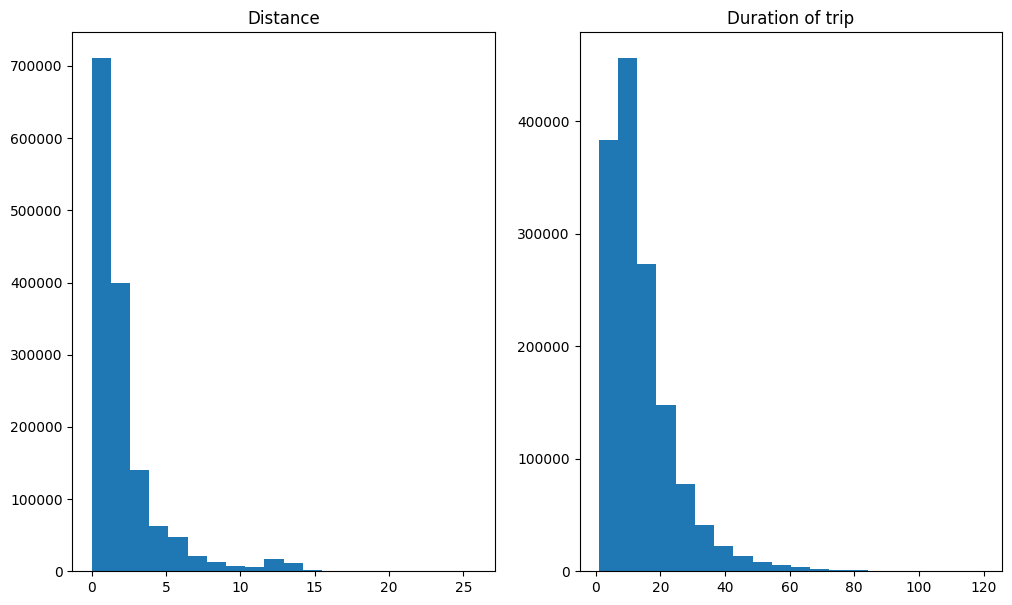

In [15]:
fig, axes = plt.subplots(1,2,figsize=(12,7))
axes[0].hist(df['distance'],bins=20)
axes[0].set_title("Distance")
axes[1].hist(df['trip_duration'],bins=20)
axes[1].set_title("Duration of trip")

In [16]:
feature = ['trip_duration','distance']
df[feature].corr(method='pearson')

,trip_duration,distance
trip_duration,1.00,0.77
distance,0.77,1.00


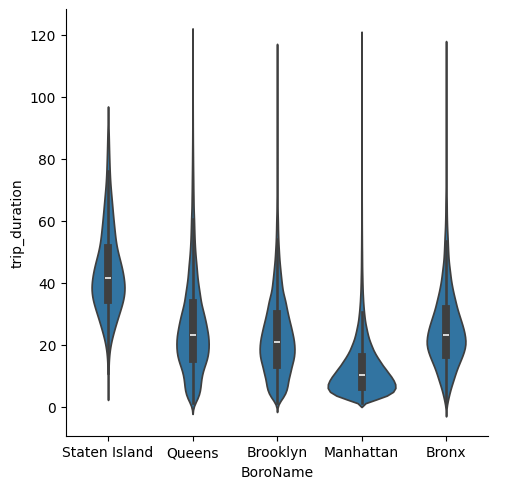

In [20]:
sns.catplot(df,x='BoroName',y = 'trip_duration',kind='violin')
plt.savefig(FIGURES_DIR / "trip_duration_borough.png")